

---



#**DATA CLEANING**

---



## **DATASET CHECKING**


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder

This code brings in useful tools to help work with data. It uses pandas and numpy to handle and change data easily. For making charts and graphs, it uses matplotlib and seaborn. The missingno tool helps show where data might be missing. It also includes tools from sklearn to prepare data before using it in a machine learning model. These tools include LabelEncoder and OneHotEncoder to change words into numbers, and MinMaxScaler and StandardScaler to make sure numbers are on the same scale.

In [ ]:
df = pd.read_csv("diabetes_prediction_dataset.csv", delimiter=",")
print(df.head())

df.shape
df.columns

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

This code reads a CSV file named "diabetes_prediction_dataset.csv" and shows the first few rows to give a quick look at the data. The df = pd.read_csv(...) line loads the file into a DataFrame called df. The print(df.head()) line prints the first 5 rows. The df.shape shows the number of rows and columns in the data, and df.columns lists all the column names.

In [ ]:
df.head()
df.info()
df.dtypes
df.head()
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   a

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


This part of the code is used to take a closer look at the dataset. The df.head() command shows the first few rows so you can quickly see what the data looks like. The df.info() line gives a summary, including how many rows there are, the column names, and if any data is missing. The df.dtypes shows the type of data in each column, like numbers or text. These steps are useful for understanding the structure of the dataset before working with it.

In [ ]:
# Renaming columns

df.columns = ['gender', 'age', 'hypertension',
                'heart_disease', 'smoking_history','bmi_score',
                'haemoglobin_level', 'blood_glucose_level', 'is_diabetic']

This part of the code renames the columns in the dataset to make them easier to read and understand, especially during data cleaning and analysis. The new names like 'gender', 'age', 'bmi_score', and 'is_diabetic' are simpler and more descriptive. This helps avoid confusion and makes the code clearer when working with the data later on.

## HANDLING MISSING VALUES

In [ ]:
for column in df:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Missing values in {column}:", df[column].isnull().sum())
    print()

missing_values = df.isnull().sum()
print(missing_values.to_dict())

df.dropna(axis=1, how='all', inplace=True)

print("Remaining columns:")
print(df.columns)

df.dropna(inplace=True)

print("Shape of DataFrame after removing rows with missing values:", df.shape)

Unique values in age: 81
Missing values in age: 0

Unique values in hypertension: 2
Missing values in hypertension: 0

Unique values in heart_disease: 2
Missing values in heart_disease: 0

Unique values in bmi_score: 4247
Missing values in bmi_score: 0

Unique values in haemoglobin_level: 18
Missing values in haemoglobin_level: 0

Unique values in blood_glucose_level: 18
Missing values in blood_glucose_level: 0

Unique values in is_diabetic: 2
Missing values in is_diabetic: 0

Unique values in gender_Female: 2
Missing values in gender_Female: 0

Unique values in gender_Male: 2
Missing values in gender_Male: 0

Unique values in gender_Other: 2
Missing values in gender_Other: 0

Unique values in smoking_history_current: 2
Missing values in smoking_history_current: 0

Unique values in smoking_history_former: 2
Missing values in smoking_history_former: 0

Unique values in smoking_history_never: 2
Missing values in smoking_history_never: 0

Unique values in smoking_history_no info: 2
Missin

This part of the code checks each column to see how many unique values it has and how many missing values are present. It then shows the total number of missing values in all columns. After that, it removes any columns that have only missing values using df.dropna(axis=1, how='all'). Then, it removes any rows that contain missing values using df.dropna(). Finally, it prints the remaining column names and shows the new shape of the DataFrame. This helps clean the dataset so it’s ready for analysis or machine learning without errors caused by missing data.









## HANDLING DUPLICATES

In [ ]:
for column in df.columns:
    print(f"Unique values in {column}:", df[column].nunique())
    print(f"Number of duplicates in '{column}' column: {df[column].duplicated().sum()} \n")

unique_columns = []
for column in df.columns:
    if df[column].nunique() == len(df):
        unique_columns.append(column)

print("Columns where each row is unique:")
print(unique_columns)

for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())
    print()

Unique values in gender: 3
Number of duplicates in 'gender' column: 99997 

Unique values in age: 102
Number of duplicates in 'age' column: 99898 

Unique values in hypertension: 2
Number of duplicates in 'hypertension' column: 99998 

Unique values in heart_disease: 2
Number of duplicates in 'heart_disease' column: 99998 

Unique values in smoking_history: 6
Number of duplicates in 'smoking_history' column: 99994 

Unique values in bmi_score: 4247
Number of duplicates in 'bmi_score' column: 95753 

Unique values in haemoglobin_level: 18
Number of duplicates in 'haemoglobin_level' column: 99982 

Unique values in blood_glucose_level: 18
Number of duplicates in 'blood_glucose_level' column: 99982 

Unique values in is_diabetic: 2
Number of duplicates in 'is_diabetic' column: 99998 

Columns where each row is unique:
[]
Unique values in column 'gender':
['Female' 'Male' 'Other']

Unique values in column 'age':
[80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   

This part of the code helps identify unique values and duplicates in each column of the dataset. It loops through all columns to print the number of unique values and the number of duplicate entries for each column. The second part checks which columns have only unique values in each row (i.e., columns where the number of unique values is equal to the total number of rows) and stores those columns in a list called unique_columns. Finally, it prints out the unique values in each column, allowing you to see the distinct entries. This helps to identify any columns that might not provide useful information, such as an ID column with unique identifiers.

In [ ]:
print("Number of duplicate rows in the dataset: ", df.duplicated().sum())

df = df.drop_duplicates()

print(f"Number of Duplcate rows after deleting duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows in the dataset:  190
Number of Duplcate rows after deleting duplicate rows: 0


This code checks for duplicate rows in the dataset. The line df.duplicated().sum() counts the number of duplicate rows (rows that are identical to others). It then removes any duplicate rows using df.drop_duplicates() and prints the number of duplicates again to show how many are left. This helps ensure that the dataset doesn’t have repeated entries, which could affect analysis or modeling.

## HANDLING OUTLIERS

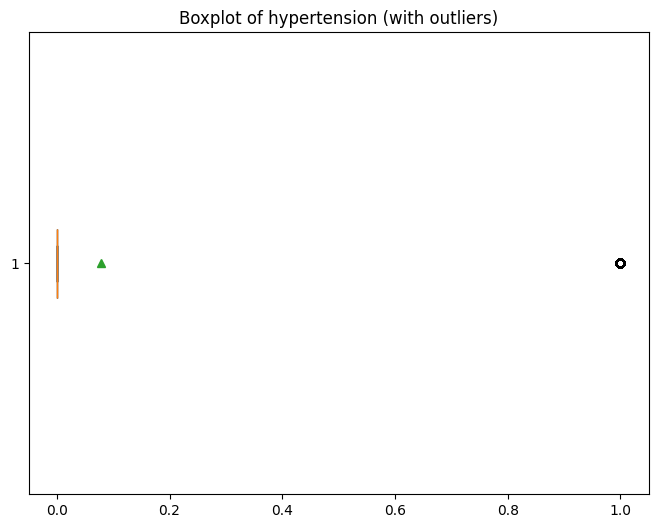

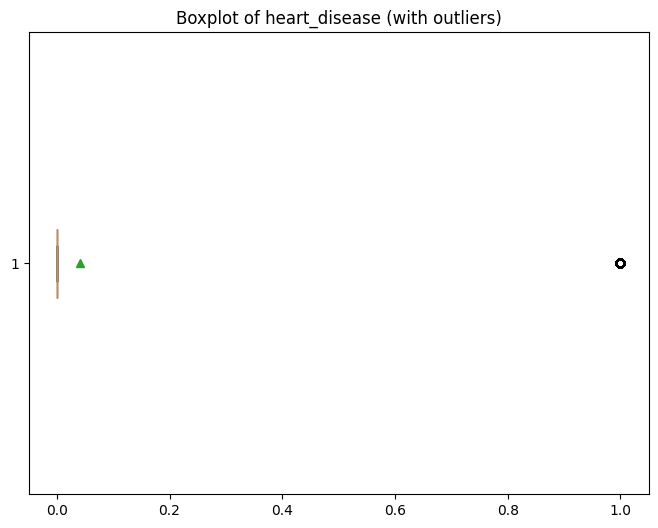

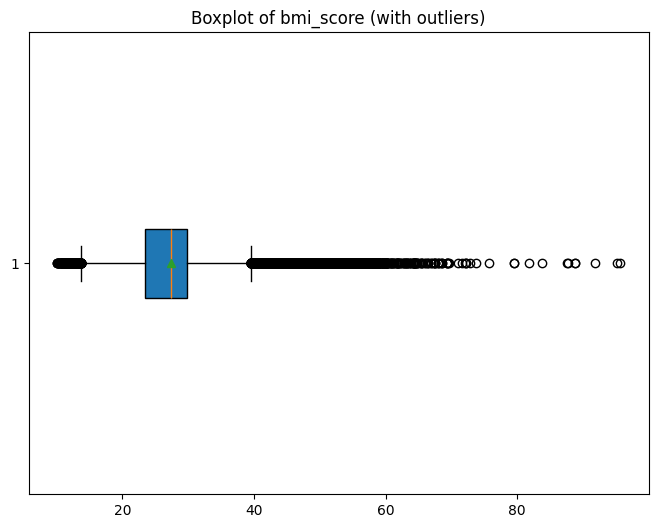

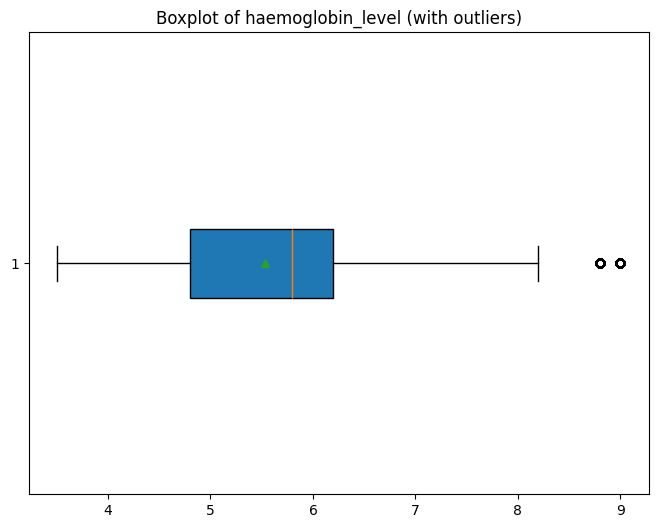

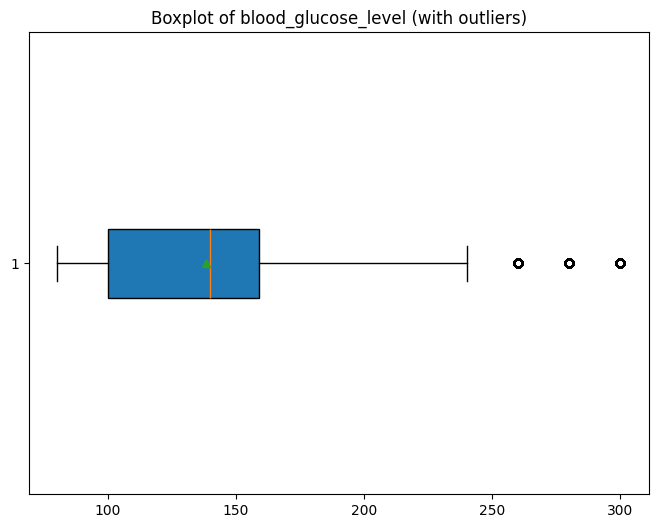

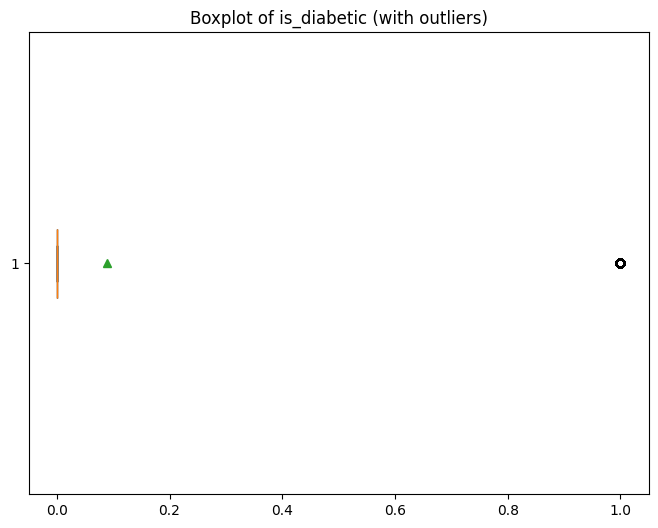

In [ ]:
def detect_outliers_iqr(df):
    outliers = {}
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
        if not column_outliers.empty:
            outliers[column] = column_outliers
    return outliers

outliers_iqr = detect_outliers_iqr(df)

for column, values in outliers_iqr.items():
    plt.figure(figsize=(8, 6))
    plt.boxplot(df[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (with outliers)')
    plt.show()

This code defines a function detect_outliers_iqr() that identifies outliers in the dataset using the Interquartile Range (IQR) method. It calculates the first and third quartiles (Q1 and Q3) and the IQR for each numerical column, then identifies values outside the bounds of Q1 - 1.5 * IQR and Q3 + 1.5 * IQR as outliers. The function stores the outliers in a dictionary, which is then used to create boxplots for each column with outliers. The boxplots visualize the distribution of the data and highlight the outliers, helping to identify and assess extreme values in the dataset.

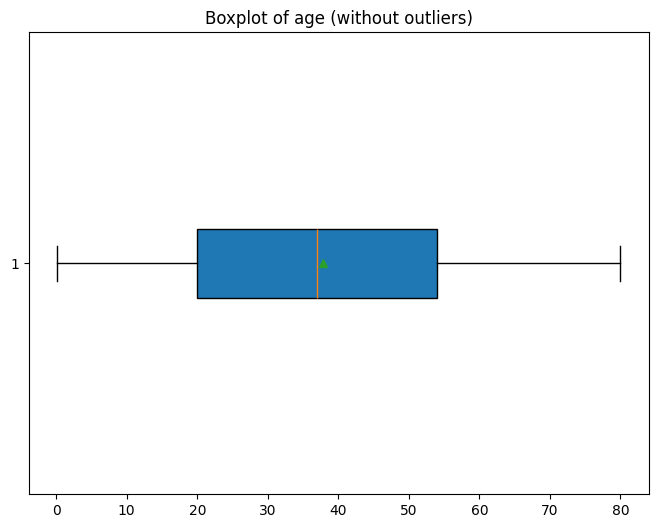

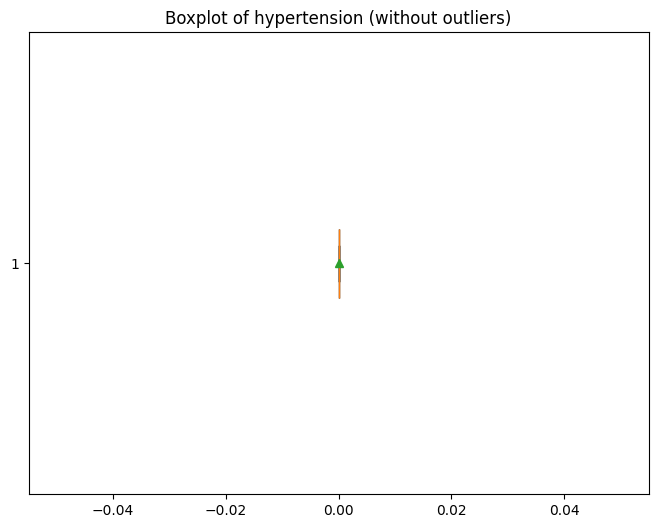

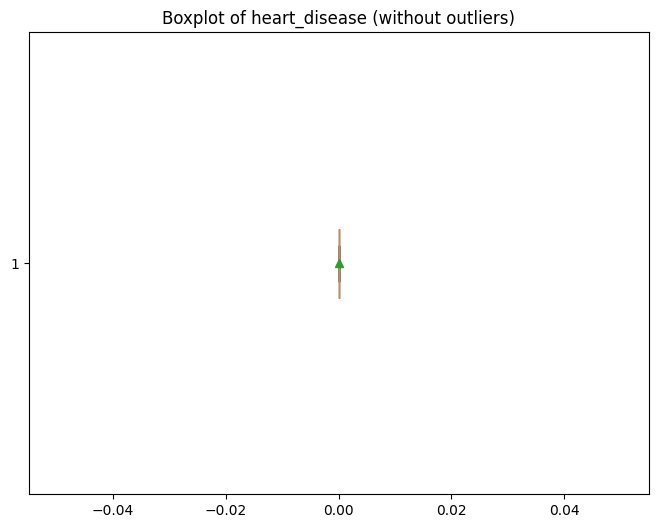

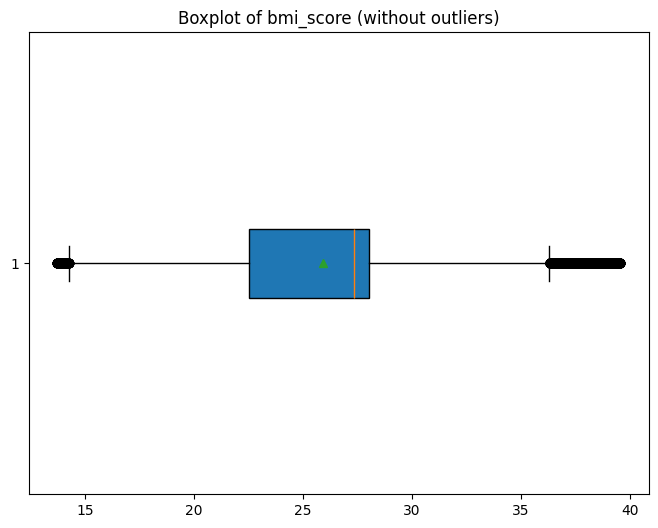

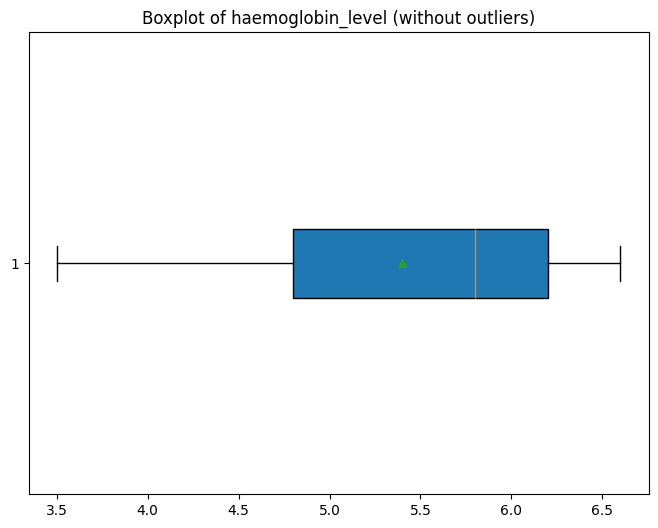

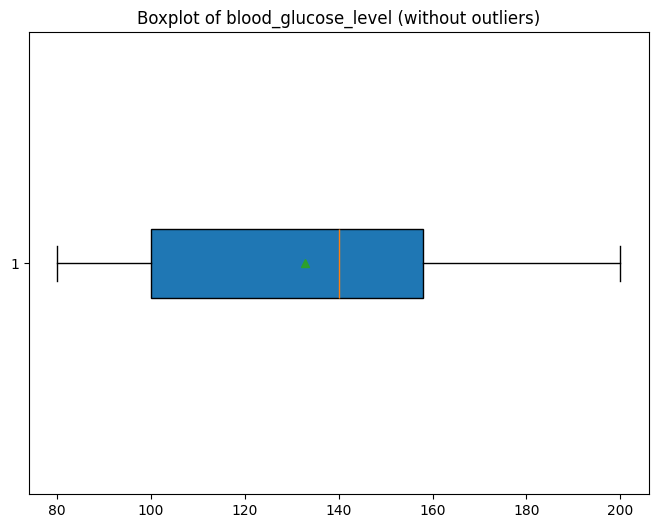

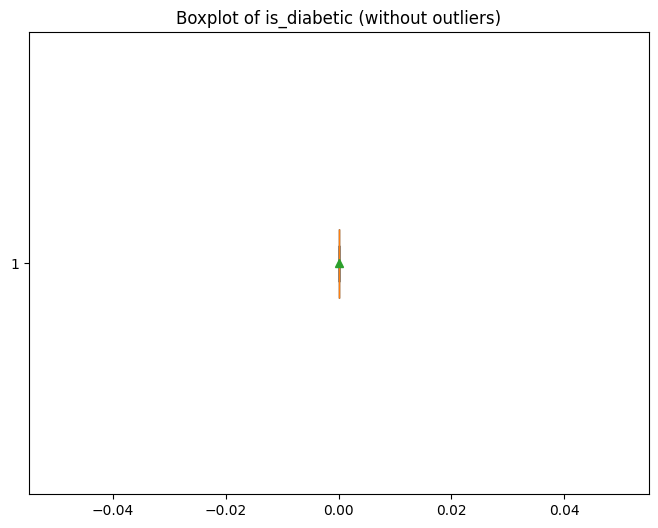

In [ ]:
def remove_outliers_iqr(df):
    cleaned_df = df.copy()
    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]
    return cleaned_df

df_cleaned = remove_outliers_iqr(df)

for column in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(df_cleaned[column], vert=False, patch_artist=True, showmeans=True)
    plt.title(f'Boxplot of {column} (without outliers)')
    plt.show()

This code defines a function remove_outliers_iqr() that removes outliers from the dataset using the Interquartile Range (IQR) method. It calculates the first and third quartiles (Q1 and Q3), determines the IQR, and identifies the lower and upper bounds for normal values in each numerical column. Rows with values outside these bounds are excluded from the dataset. The cleaned DataFrame is returned without the outliers. After cleaning, the code generates boxplots for each numerical column in the cleaned dataset, visually showing the data distribution without the outliers. This helps to ensure the dataset is free from extreme values that might distort analysis or modeling.

## CHECKING THE COUNT AND VALUE OF RECORDS PER CATEGORY

In [ ]:

df.value_counts()


gender  age    hypertension  heart_disease  smoking_history  bmi_score  haemoglobin_level  blood_glucose_level  is_diabetic
Other   55.00  0             0              No Info          27.32      5.0                158                  0              1
Female  0.08   0             0              No Info          11.88      5.7                80                   0              1
Other   10.00  0             0              not current      14.09      5.0                140                  0              1
        7.00   0             0              No Info          27.32      3.5                159                  0              1
Male    80.00  1             1              not current      34.56      6.2                145                  0              1
                                                                                                                              ..
Female  0.08   0             0              No Info          13.03      6.2                158                  0              1
                                                             12.82      3.5                90                   0              1
                                                             12.77      4.5                160                  0              1
                                                             12.74      3.5                140                  0              1
                                                             12.50      4.5                155                  0              1
Name: count, Length: 96146, dtype: int64

The df.value_counts() function counts the number of occurrences of each unique value in the dataset. It is usually applied to a specific column, but if you call it on the entire DataFrame (df.value_counts()), it will give the counts of unique rows across all columns combined. It is helpful for understanding the distribution of values and identifying any imbalances or patterns in categorical data. However, if used on a large DataFrame with many columns, it might produce a lengthy output.

In [ ]:
print(df.age.max())
print(df.age.min())

80.0
0.08


This code is used to find the highest and lowest values in the age column of the dataset. The df.age.max() function returns the maximum age, while df.age.min() returns the minimum age. These values help in understanding the range of ages in the dataset and can also be useful for identifying any outliers or unrealistic values in the data, ensuring that the data is within a reasonable range.

In [ ]:
df.age = df.age.astype(int)
df.age.dtype

df.age.value_counts()

print(df.age.max())
print(df.age.min())

80
0


This code first changes the data type of the age column to integers using df.age.astype(int). The df.age.dtype line checks and confirms the data type of the age column after the conversion. Then, df.age.value_counts() is used to count how many times each unique age appears in the column. Finally, it prints the maximum and minimum values in the age column to understand the range of ages. Converting the age column to integers ensures that the values are stored as whole numbers, which is often expected for age-related data.

In [ ]:
print("BMI_SCORE:", df.bmi_score.min(), "to", df.bmi_score.max())
print("HEMOGLOBIN_LEVEL:", df.haemoglobin_level.min(), "to", df.haemoglobin_level.max())
print("BLOOD_GLUCOSE_LEVEL:", df.blood_glucose_level.min(), "to", df.blood_glucose_level.max())


BMI_SCORE: 10.01 to 95.69
HEMOGLOBIN_LEVEL: 3.5 to 9.0
BLOOD_GLUCOSE_LEVEL: 80 to 300


This code prints the range of values for three health-related columns in the dataset. It shows the minimum and maximum values for bmi_score, haemoglobin_level, and blood_glucose_level. This helps to understand the spread or range of each of these features, which can be useful for detecting any unusual values or preparing the data for further analysis, such as normalization or feature scaling.

## PREPROCESSING THE SMOKING HISTORY WITH UNNECCESARY CATEGORY

In [ ]:

df.smoking_history.value_counts()

,count
smoking_history,
never,34398
No Info,32887
former,9299
current,9197
not current,6367
ever,3998


This line of code counts how many times each unique value appears in the smoking_history column, helping to understand how smoking habits are distributed in the dataset. It shows categories like "never", "former", "current", and others. However, some entries such as "former","ever" and "not current" may be unnecessary or unclear, as they could mean the same thing or create confusion. These values might need to be cleaned or combined to make the data more consistent and easier to analyze.

In [ ]:
# cleaning Smoking_history column

def clean_smoking_history(value):

    if value == "No Info":
        return "no info"
    elif value == "ever":
        return "current"
    elif value == "not current":
        return "former"
    else:
        return value

df.smoking_history = df.smoking_history.apply(clean_smoking_history)

This code defines a function called clean_smoking_history() to clean and standardize the values in the smoking_history column. It changes "No Info" to "no info", "ever" to "current", and "not current" to "former" for consistency. Any other values are kept as they are. The function is then applied to the entire smoking_history column using .apply(). This helps make the data cleaner and easier to work with by ensuring that similar meanings are grouped under the same label.

In [ ]:
df.smoking_history.value_counts()

,count
smoking_history,
never,34398
no info,32887
former,15666
current,13195


This line of code shows how many times each unique value appears in the smoking_history column after it has been cleaned. It helps confirm that the changes, such as turning "ever" into "current" and "not current" into "former", were done correctly. It also gives a clearer view of how smoking habits are grouped in the dataset.

## CHECKING IF SMOKING HISTORY MATCHES THE AGE

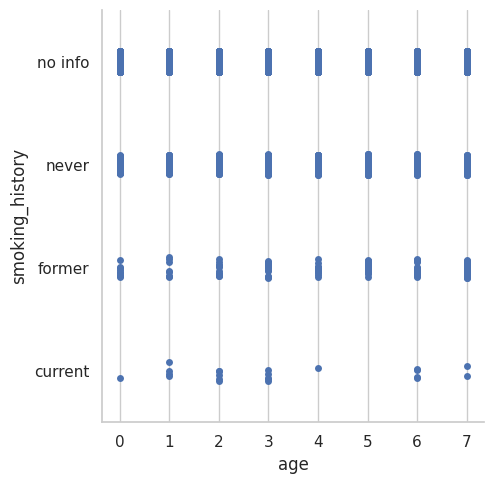

In [ ]:


sns.set(style="whitegrid")

sns.catplot(x="age", y="smoking_history", data=df.loc[df['age'] <=7])

plt.show()

This code creates a visual plot to show the relationship between age and smoking_history for rows where the age is 7 or younger. It uses Seaborn's catplot, which is good for showing the distribution of categories. The sns.set(style="whitegrid") line sets a clean background for better readability. This plot can help check for unusual or incorrect data, since very young children usually should not have a smoking history.










In [ ]:
df = df[~((df['age'] < 7) & df['smoking_history'].isin(['ever', 'current']))]

This line of code removes rows where the age is less than 7 and the smoking_history is either "ever" or "current". The ~ symbol means "not", so it keeps only the rows that do not match this condition. This helps clean the data by removing unrealistic cases, since very young children should not have a smoking history marked as "ever" or "current".

In [ ]:
df.shape

(96126, 9)

This line of code returns the shape of the DataFrame, showing the number of rows and columns after the filtering operation. It helps you check how many entries remain in the dataset after removing the unrealistic cases where the age was less than 7 and the smoking history was "ever" or "current".

## TRANSFORMING SOME COLUMN WITH NUMERICAL DATA TO CATEGORICAL

In [ ]:
df = pd.get_dummies(data=df)

df.head()

,age,hypertension,heart_disease,bmi_score,haemoglobin_level,blood_glucose_level,is_diabetic,gender_Female,gender_Male,gender_Other,smoking_history_current,smoking_history_former,smoking_history_never,smoking_history_no info
0,80,0,1,25.19,6.6,140,0,True,False,False,False,False,True,False
1,54,0,0,27.32,6.6,80,0,True,False,False,False,False,False,True
2,28,0,0,27.32,5.7,158,0,False,True,False,False,False,True,False
3,36,0,0,23.45,5.0,155,0,True,False,False,True,False,False,False
4,76,1,1,20.14,4.8,155,0,False,True,False,True,False,False,False


This code converts categorical variables in the df DataFrame into dummy/indicator variables using pd.get_dummies(). It creates a new column for each unique category in the original categorical columns, where each column contains 1 or 0 to indicate the presence of a particular category. The df.head() line then displays the first few rows of the modified DataFrame, showing the new dummy variables and how the data has been transformed. This is commonly done before applying machine learning models that require numerical input.

## Feature Scaling Using Min-Max Normalization

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

columns_to_scale = ['age', 'bmi_score','haemoglobin_level','blood_glucose_level']

scaler.fit(df[columns_to_scale])

scaled_columns = scaler.transform(df[columns_to_scale])

df[columns_to_scale] = scaled_columns

This code uses the MinMaxScaler from sklearn.preprocessing to scale numerical columns in the DataFrame, transforming the values to a range between 0 and 1. The columns selected for scaling are age, bmi_score, haemoglobin_level, and blood_glucose_level. First, the scaler is fitted to these columns using scaler.fit(). Then, the transformation is applied with scaler.transform(), and the scaled values are stored back into the original columns. This scaling is commonly done to ensure that numerical features are on the same scale, which can improve the performance of machine learning models.

In [ ]:
df.shape

(96126, 14)

## Compute correlation matrix

<ipython-input-90-119a9d61c29b>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index, palette='coolwarm')


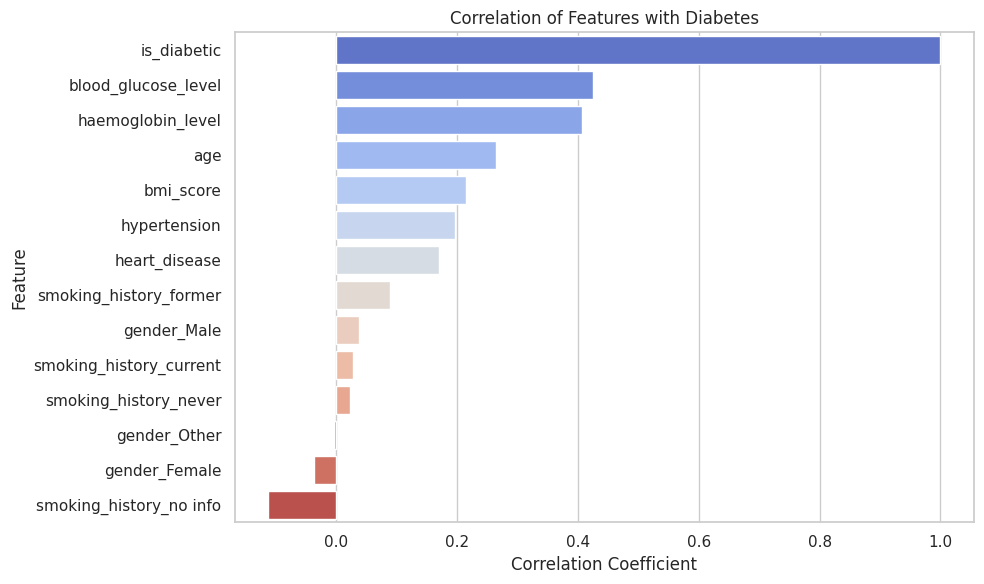

In [ ]:

correlation_matrix = df.corr()

# Get correlation with target variable 'diabetes'
correlation_with_target = correlation_matrix['is_diabetic'].sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index, palette='coolwarm')
plt.title('Correlation of Features with Diabetes')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

This code calculates the correlation matrix of the dataset using df.corr(), which computes the correlation between all numerical features. It then extracts the correlation values with the target variable is_diabetic and sorts them in descending order. A bar plot is created using Seaborn to visualize the correlation coefficients of each feature with the is_diabetic column. The plot shows how strongly each feature is related to the target variable, helping to identify the most important features for predicting diabetes. The coolwarm color palette is used to indicate the strength and direction of the correlations.

In [ ]:
# Drop multiple columns
df = df.drop(['gender_Other', 'smoking_history_no info'], axis=1)

This code removes two specific columns, gender_Other and smoking_history_no info, from the DataFrame using the df.drop() method. The axis=1 argument specifies that columns (not rows) should be dropped. This step is typically done to eliminate unnecessary or irrelevant columns from the dataset, ensuring a cleaner and more focused set of features for analysis or modeling.

In [ ]:
df.shape

(96126, 12)

## BALANCING THE DATASET

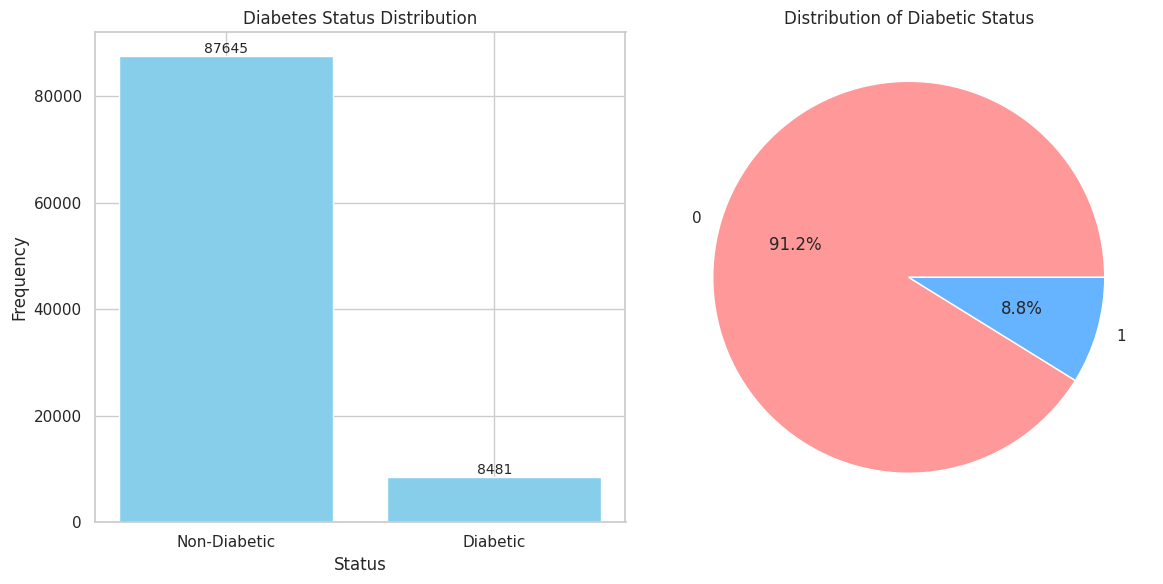

In [ ]:
# Count the occurrences of each diabetic status
status_counts = df['is_diabetic'].value_counts()

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart for the diabetic status
axes[0].bar(status_counts.index, status_counts.values, color='skyblue')

axes[0].set_title('Diabetes Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])

# Add count annotations to the bars
for idx, count in enumerate(status_counts.values):
    axes[0].text(idx, count, str(count), ha='center', va='bottom', fontsize=10)

# Pie chart for the diabetic status distribution
axes[1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('Distribution of Diabetic Status')

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plots
plt.show()


This dataset, after some cleaning, still has 87,645 non-diabetic (0) instances and 8,481 diabetic (1) instances, resulting in a noticeable imbalance between the two classes. Such an imbalance can pose a challenge for machine learning models, as they may become biased towards predicting the majority class (non-diabetic) more often, leading to poor performance in predicting the minority class (diabetic). This imbalance can significantly affect the model's ability to correctly identify diabetic cases, which are often more critical to predict accurately. To address this issue, techniques such as oversampling the diabetic (minority) class, undersampling the non-diabetic (majority) class, or adjusting class weights within the model can be applied. These methods help ensure that the model learns to recognize patterns in both classes effectively, improving its overall predictive accuracy.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import pandas as pd

# Split the dataset into features (X) and target (y)
X_features = df.drop(columns='is_diabetic')
y_target = df['is_diabetic']

# Step 1: Apply SMOTE to create a balanced dataset by oversampling the minority class
smote_technique = SMOTE(random_state=42)
X_resampled, y_resampled = smote_technique.fit_resample(X_features, y_target)

# Step 2: Combine the resampled features and target into a DataFrame for easier handling
df_resampled = pd.DataFrame(X_resampled)
df_resampled['is_diabetic'] = y_resampled

# Step 3: Downsample the resampled dataset to a fixed number of 10,000 rows
df_downsampled = resample(df_resampled, replace=False, n_samples=10000, random_state=42)

# Check the distribution of the classes in the final balanced dataset
print("Balanced Class Distribution:")
print(df_downsampled['is_diabetic'].value_counts())


Balanced Class Distribution:
is_diabetic
1    5039
0    4961
Name: count, dtype: int64


This code addresses the class imbalance in the dataset by applying the SMOTE technique to oversample the minority class (diabetic individuals), creating synthetic samples to balance the dataset. After SMOTE is applied, the dataset is downsampled to 10,000 rows to ensure a manageable size while maintaining balance. The final dataset is then checked for class distribution to verify that the diabetic and non-diabetic classes are now more evenly represented. This process helps mitigate the risk of bias in machine learning models that could otherwise favor the majority class due to the original imbalance.

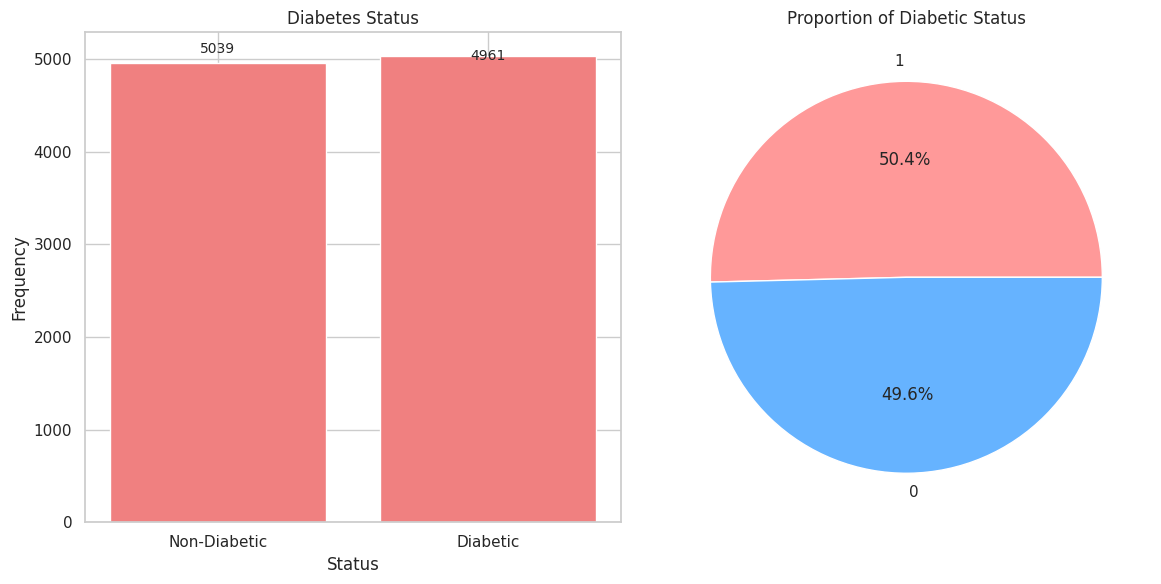

In [ ]:
# Count the distribution of diabetic status in the balanced dataset
status_distribution = df_balanced['is_diabetic'].value_counts()

# Create subplots for the bar chart and pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart for diabetic status distribution
axes[0].bar(status_distribution.index, status_distribution.values, color='lightcoral')

axes[0].set_title('Diabetes Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Frequency')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])

# Annotate the bars with their respective counts
for idx, count in enumerate(status_distribution.values):
    axes[0].text(idx, count, str(count), ha='center', va='bottom', fontsize=10)

# Pie chart for the diabetic status distribution
axes[1].pie(status_distribution, labels=status_distribution.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('Proportion of Diabetic Status')

# Adjust layout for better spacing between plots
plt.tight_layout()

# Display the plots
plt.show()


This code visualizes the distribution of diabetic and non-diabetic individuals in the dataset after applying SMOTE and downsampling to balance the classes. It uses a bar chart to show the count of each class, with annotations for clarity, and a pie chart to display the proportion of diabetic versus non-diabetic individuals. These visualizations confirm that the dataset is now balanced, addressing the class imbalance issue. By ensuring equal representation of both classes, the balanced dataset provides a more reliable foundation for training machine learning models, minimizing bias towards the majority class.

In [ ]:
df_balanced

,age,hypertension,heart_disease,bmi_score,haemoglobin_level,blood_glucose_level,gender_Female,gender_Male,smoking_history_current,smoking_history_former,smoking_history_never,is_diabetic
17024,0.687500,0,0,0.218137,0.418182,0.209091,True,False,True,False,False,0
95818,0.687500,0,0,0.202848,0.272727,0.227273,True,False,False,True,False,0
174186,0.106951,0,0,0.104652,0.504036,0.887213,True,False,False,False,False,1
144831,0.850000,0,0,0.218527,0.952752,0.818182,True,False,False,False,True,1
120226,0.532043,0,0,0.186521,0.963636,0.656208,False,True,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
46183,0.062500,0,0,0.047852,0.545455,0.354545,True,False,False,False,False,0
92291,0.500000,0,0,0.250817,0.000000,0.340909,True,False,False,False,True,0
73746,0.175000,0,0,0.163632,0.000000,0.363636,False,True,False,False,False,0
163311,0.697313,0,0,0.290451,0.600000,0.727273,True,False,False,False,True,1


The df_balanced DataFrame represents the dataset after applying SMOTE to oversample the minority class (diabetic individuals) and then downsampling the resulting balanced data to a total of 10,000 rows. This ensures that both the diabetic and non-diabetic classes are equally represented, mitigating the issues caused by class imbalance. The dataset now contains a more balanced distribution of the target variable (is_diabetic), which is crucial for building fair and unbiased machine learning models.

In [ ]:
df_balanced.shape
df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 17024 to 94546
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      10000 non-null  float64
 1   hypertension             10000 non-null  int64  
 2   heart_disease            10000 non-null  int64  
 3   bmi_score                10000 non-null  float64
 4   haemoglobin_level        10000 non-null  float64
 5   blood_glucose_level      10000 non-null  float64
 6   gender_Female            10000 non-null  bool   
 7   gender_Male              10000 non-null  bool   
 8   smoking_history_current  10000 non-null  bool   
 9   smoking_history_former   10000 non-null  bool   
 10  smoking_history_never    10000 non-null  bool   
 11  is_diabetic              10000 non-null  int64  
dtypes: bool(5), float64(4), int64(3)
memory usage: 673.8 KB


The df_balanced.shape and df_balanced.info() functions provide an overview of the structure and characteristics of the balanced dataset. The .shape function returns the dimensions of the DataFrame, showing the number of rows and columns after applying SMOTE and downsampling. Meanwhile, .info() gives detailed information about the dataset, including the number of non-null entries in each column, the data types of the columns, and whether there are any remaining missing values. These steps ensure that the dataset is properly structured and ready for further analysis or model training.

In [ ]:
# Exporting cleaned data into .csv file

df_balanced.to_csv("diabetes_clean.csv", index = False)

This line of code exports the df_balanced DataFrame into a CSV file named "diabetes_clean.csv". The index=False argument ensures that the index column is not included in the exported file. This is useful for saving the cleaned and balanced dataset for future use, such as training machine learning models or sharing the dataset with others. The resulting CSV file will contain the processed data, with balanced diabetic and non-diabetic instances.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



---


# **MLP Code Explanation**

---



In [ ]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


This first part of the code is responsible for importing all necessary libraries needed for the experiment.

* **pandas** is used for data manipulation and handling
data frames.
* **sklearn.neural_network** provides **MLPClassifier**, the main model used to build and train the Multi-Layer Perceptron (MLP).
* **train_test_split** from sklearn.model_selection is used to split the dataset into training and testing sets.
* **StandardScaler** is used for standardizing the features so that they have a mean of 0 and variance of 1, which helps neural networks converge faster and perform better.
* Metrics like **classification_report, confusion_matrix, and f1_score** are imported to evaluate the model’s performance after training.
* **matplotlib.pyplot and seaborn** are included for visualization, such as plotting confusion matrices and performance graphs.
* **numpy** is imported for efficient numerical operations throughout the code.

This setup ensures all tools needed for data preparation, model building, training, evaluation, and visualization are ready.

In [ ]:
df = pd.read_csv('diabetes_clean.csv')


X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

* pd.read_csv('diabetes_clean.csv') reads the cleaned diabetes dataset into a pandas DataFrame called df.

* X = df.drop(columns=['is_diabetic']) separates the feature columns (all input variables) by dropping the target column 'is_diabetic'.

* y = df['is_diabetic'] isolates the target variable, which indicates whether a patient is diabetic or not (1 or 0).

This separation of features (X) and target (y) is essential for training the MLP model, where X will be used as input and y as the ground truth for learning.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

* train_test_split(X, y, random_state=0) splits the
dataset into training and testing subsets. Using random_state=0 ensures the split is reproducible (same split every time).

* StandardScaler() is used to normalize the feature values. Since MLPs are sensitive to feature scales, scaling ensures that all features contribute equally to the learning process.

* fit_transform(X_train) learns the scaling parameters from the training data and applies the transformation.

* transform(X_test) applies the same scaling to the testing data without refitting.

This scaling step is crucial for faster convergence and better model performance.

In [ ]:
nnclf = MLPClassifier(hidden_layer_sizes=[100], activation='relu', solver='adam', learning_rate_init=0.01, max_iter=1000, random_state=0)

The line of code defines the MLP model and its hyperparameters.

**I. Number of hidden layers:**

The hidden_layer_sizes=[100] defines 1 hidden layer. Each element in the list corresponds to one hidden layer, so a single value means there is only one hidden layer.

**II. Number of neurons per layer:**

The single hidden layer has 100 neurons. The value inside the list (100) indicates the number of neurons.

**III. Activation functions (e.g., ReLU, sigmoid, tanh):**

The activation function is ReLU (activation='relu'). ReLU (Rectified Linear Unit) introduces non-linearity into the network and is effective for avoiding vanishing gradients.

**IV. Optimization algorithms (e.g., Adam, SGD):**

The optimizer is Adam (solver='adam'). Adam is an adaptive learning rate optimization algorithm that combines ideas from RMSProp and SGD with momentum, making it efficient and reliable for neural networks.

**V. Learning rate:**

The initial learning rate is set to 0.01 (learning_rate_init=0.01). It controls how much the model weights are updated during training.

**VI. Batch size:**

No batch size is explicitly defined in this code, so MLPClassifier automatically uses 'auto', which generally means minibatches of size min(200, n_samples). Batch sizes are unable to be declared when the 'adam' solver is being used.

**VII. Number of epochs:**

The maximum number of iterations (epochs) is set to 1000 (max_iter=1000). The model will perform up to 1000 passes over the training data unless convergence is achieved earlier.

In [ ]:
nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

The model is trained using the .fit() function, where the X_train and y_train datasets are provided to allow the MLP classifier to learn the patterns in the data. After training, the model is tested by predicting probabilities for the first test sample using .predict_proba(X_test[:1]). This function outputs the probability estimates for each class (non-diabetic or diabetic). Additionally, .predict(X_test[:5]) is used to make direct class predictions for the first five samples of the test set, providing the predicted labels (either 0 for non-diabetic or 1 for diabetic). These early predictions help verify that the model is functioning and give a quick glance at how it might perform on unseen data.

In [ ]:
score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

After training, the model's performance is evaluated using .score(), which calculates the overall accuracy based on correct predictions over the total number of samples. The train_acc and test_acc store the training and testing accuracy respectively, allowing a quick check for overfitting or underfitting. Additionally, the F1 score is calculated using f1_score(), which considers both precision and recall, providing a more balanced performance measure especially important for medical datasets like diabetes prediction where false positives and false negatives both carry significant risks.

In [ ]:
y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

The model's detailed performance is further assessed through a classification report generated by classification_report(), which displays precision, recall, F1 score, and support for each class ("Non-Diabetic" and "Diabetic"). This breakdown provides a deeper understanding of the model's strengths and weaknesses across different classes. Finally, the training accuracy, testing accuracy, and average F1 score are printed, offering a concise summary of the model's predictive reliability and balance between sensitivity and specificity.

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

The confusion matrix is computed using confusion_matrix() to visualize the counts of true positives, true negatives, false positives, and false negatives, helping to diagnose specific prediction errors. A heatmap is then plotted using Seaborn to clearly display these values, with class labels on both axes for easy interpretation. This graphical representation enhances the understanding of how well the MLP model distinguishes between diabetic and non-diabetic patients.



---



# **MLP Model Experimentation**


---



### **BEST MLP MODEL - Experiment 57**

Probability Results:  [[0.02627193 0.97372807]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9124

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.93      0.91      1264
    Diabetic (1)       0.92      0.90      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9345
Testing Accuracy:  0.9124
Avg F1 Score:      0.9103
Confusion Matrix:
 [[1170   94]
 [ 125 1111]]


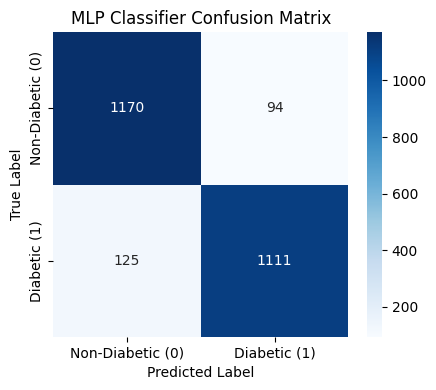

In [ ]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100], activation='relu', solver='adam', learning_rate_init=0.01, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **BEST Hyperparameter 1 MODEL - Experiment 1**

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Probability Results:  [[0. 1.]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8988

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.90      0.90      1264
    Diabetic (1)       0.90      0.90      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.9817
Testing Accuracy:  0.8988
Avg F1 Score:      0.8979
Confusion Matrix:
 [[1135  129]
 [ 124 1112]]


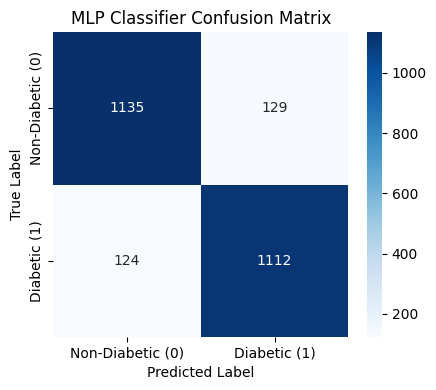

In [2]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100], solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **BEST Hyperparameter 2 MODEL - Experiment 13**

Probability Results:  [[0. 1.]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9052

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.90      0.91      1264
    Diabetic (1)       0.90      0.91      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 1.0000
Testing Accuracy:  0.9052
Avg F1 Score:      0.9051
Confusion Matrix:
 [[1133  131]
 [ 106 1130]]


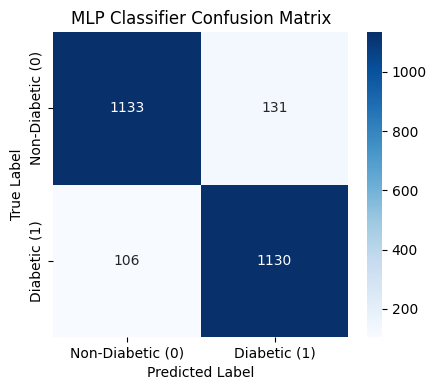

In [7]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[150,100,50], solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 3 (relu) MODEL - Experiment 22**

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Probability Results:  [[0. 1.]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9016

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.89      0.90      1264
    Diabetic (1)       0.89      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.9975
Testing Accuracy:  0.9016
Avg F1 Score:      0.9017
Confusion Matrix:
 [[1126  138]
 [ 108 1128]]


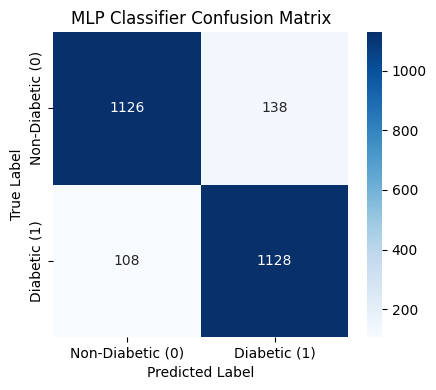

In [9]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50,25], activation = 'relu', solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 3 (tanh) MODEL - Experiment 29**

Probability Results:  [[3.1197267e-13 1.0000000e+00]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8956

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.89      0.90      1264
    Diabetic (1)       0.89      0.90      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.9999
Testing Accuracy:  0.8956
Avg F1 Score:      0.8951
Confusion Matrix:
 [[1125  139]
 [ 122 1114]]


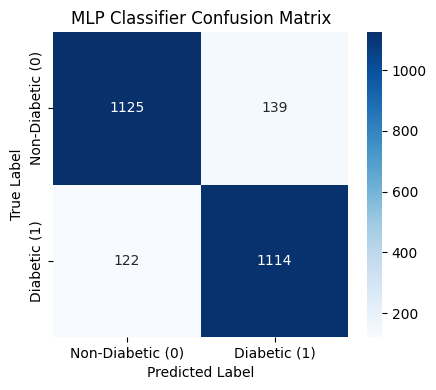

In [8]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50], activation = 'tanh', solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 4 (sgd) MODEL - Experiment 36**

Probability Results:  [[0.099486 0.900514]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.91

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.92      0.90      0.91      1264
    Diabetic (1)       0.90      0.92      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9276
Testing Accuracy:  0.9100
Avg F1 Score:      0.9103
Confusion Matrix:
 [[1134  130]
 [  95 1141]]


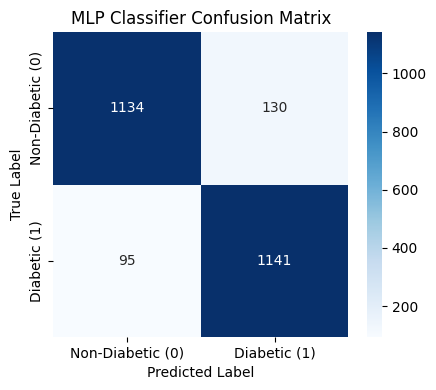

In [13]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[50], activation = 'relu', solver='adam', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 4 (sgd) MODEL - Experiment 51**

Probability Results:  [[0.30071042 0.69928958]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8988

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.89      0.90      1264
    Diabetic (1)       0.89      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.8969
Testing Accuracy:  0.8988
Avg F1 Score:      0.8984
Confusion Matrix:
 [[1128  136]
 [ 117 1119]]


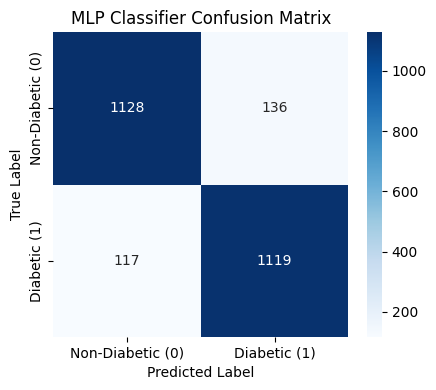

In [14]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50,25], activation = 'relu', solver='sgd', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 5 (adam) MODEL - Experiment 57**

Probability Results:  [[0.02627193 0.97372807]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9124

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.93      0.91      1264
    Diabetic (1)       0.92      0.90      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9345
Testing Accuracy:  0.9124
Avg F1 Score:      0.9103
Confusion Matrix:
 [[1170   94]
 [ 125 1111]]


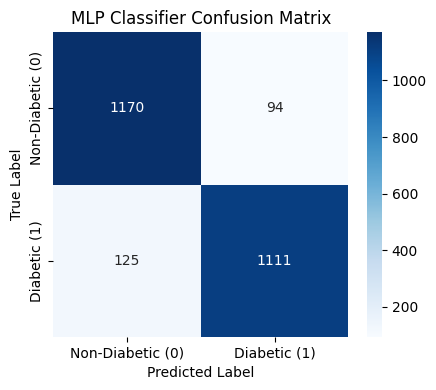

In [15]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100], activation = 'relu', solver='adam', learning_rate_init=.01, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 5 (sgd) MODEL - Experiment 74**

Probability Results:  [[0.30071042 0.69928958]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8988

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.89      0.90      1264
    Diabetic (1)       0.89      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.8969
Testing Accuracy:  0.8988
Avg F1 Score:      0.8984
Confusion Matrix:
 [[1128  136]
 [ 117 1119]]


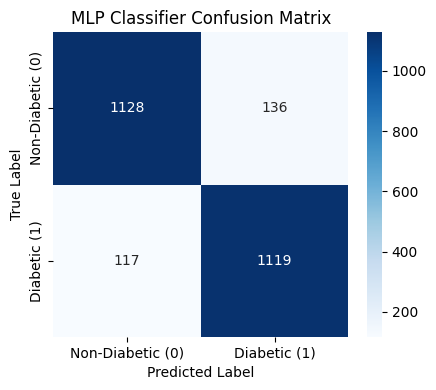

In [16]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50,25], activation = 'relu', solver='sgd', learning_rate='constant', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 6 MODEL - Experiment 94**

Probability Results:  [[0.11825497 0.88174503]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9088

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.92      0.90      0.91      1264
    Diabetic (1)       0.90      0.92      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9381
Testing Accuracy:  0.9088
Avg F1 Score:      0.9087
Confusion Matrix:
 [[1137  127]
 [ 101 1135]]


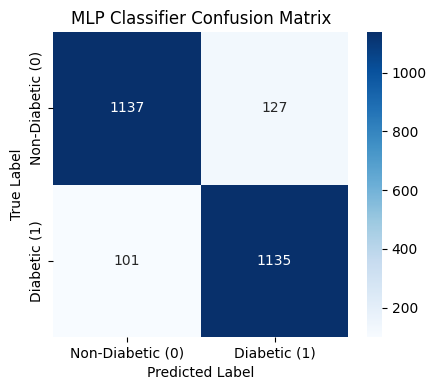

In [24]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50,25], activation='relu', solver='sgd', learning_rate='adaptive', batch_size=128, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Best Hyperparameter 7 MODEL - Experiment 107**

Probability Results:  [[0.02627193 0.97372807]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9124

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.93      0.91      1264
    Diabetic (1)       0.92      0.90      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9345
Testing Accuracy:  0.9124
Avg F1 Score:      0.9103
Confusion Matrix:
 [[1170   94]
 [ 125 1111]]


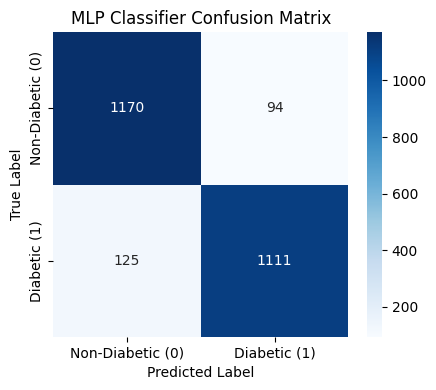

In [27]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100], activation='relu', solver='adam', learning_rate_init=0.01, max_iter=500, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

---



# **Other Models Mentioned in the IEEE Paper**


---

### **Hyperparameter 1 MODEL - Experiment 3**

Probability Results:  [[0. 1.]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9016

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.90      0.90      1264
    Diabetic (1)       0.90      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 1.0000
Testing Accuracy:  0.9016
Avg F1 Score:      0.9011
Confusion Matrix:
 [[1133  131]
 [ 115 1121]]


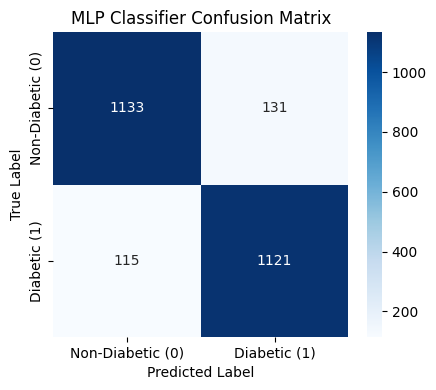

In [3]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,100,100], solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 2 MODEL - Experiment 6**

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Probability Results:  [[3.45815637e-05 9.99965418e-01]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9028

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.91      0.90      1264
    Diabetic (1)       0.90      0.90      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.9524
Testing Accuracy:  0.9028
Avg F1 Score:      0.9016
Confusion Matrix:
 [[1144  120]
 [ 123 1113]]


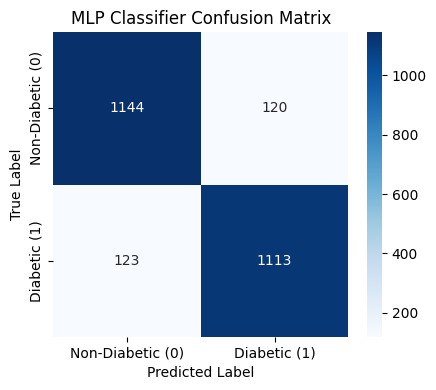

In [5]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[50], solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 2 MODEL - Experiment 15**

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Probability Results:  [[1.0000000e+00 1.1594087e-58]]
Prediction Results:  [0 1 0 0 0]
Overall Accuracy:  0.8948

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.89      0.90      1264
    Diabetic (1)       0.89      0.90      0.89      1236

        accuracy                           0.89      2500
       macro avg       0.89      0.89      0.89      2500
    weighted avg       0.89      0.89      0.89      2500

Training Accuracy: 1.0000
Testing Accuracy:  0.8948
Avg F1 Score:      0.8943
Confusion Matrix:
 [[1125  139]
 [ 124 1112]]


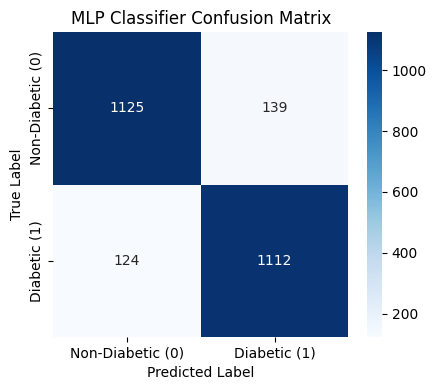

In [6]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,75,50,25], solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 3 MODEL - Experiment 20**

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Probability Results:  [[3.12516679e-11 1.00000000e+00]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8956

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.89      0.90      0.90      1264
    Diabetic (1)       0.90      0.89      0.89      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 1.0000
Testing Accuracy:  0.8956
Avg F1 Score:      0.8941
Confusion Matrix:
 [[1137  127]
 [ 134 1102]]


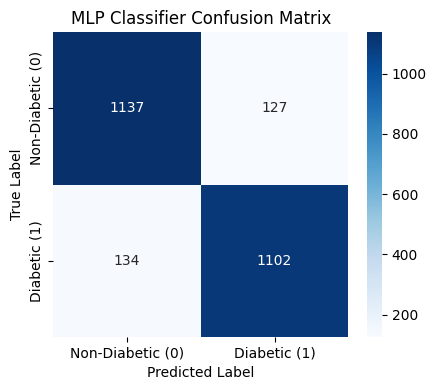

In [10]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[150,75], activation = 'relu', solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 3 MODEL - Experiment 23**

Probability Results:  [[0. 1.]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9052

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.90      0.91      1264
    Diabetic (1)       0.90      0.91      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 1.0000
Testing Accuracy:  0.9052
Avg F1 Score:      0.9051
Confusion Matrix:
 [[1133  131]
 [ 106 1130]]


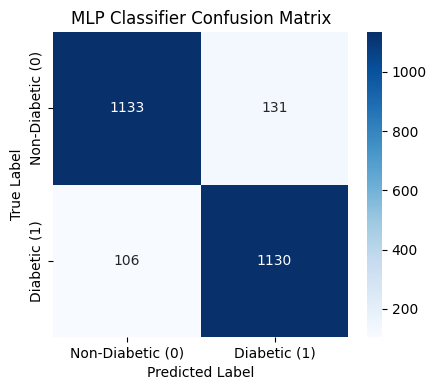

In [11]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[150,100,50], activation = 'relu', solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 3 MODEL - Experiment 24**

Probability Results:  [[0. 1.]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9016

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.90      0.90      1264
    Diabetic (1)       0.90      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 1.0000
Testing Accuracy:  0.9016
Avg F1 Score:      0.9011
Confusion Matrix:
 [[1133  131]
 [ 115 1121]]


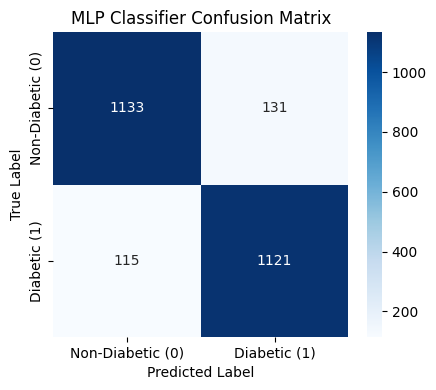

In [12]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,100,100], activation = 'relu', solver='lbfgs', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 5 MODEL - Experiment 56**

Probability Results:  [[0.0820159 0.9179841]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9048

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.92      0.91      1264
    Diabetic (1)       0.91      0.89      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.91      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.9329
Testing Accuracy:  0.9048
Avg F1 Score:      0.9027
Confusion Matrix:
 [[1158  106]
 [ 132 1104]]


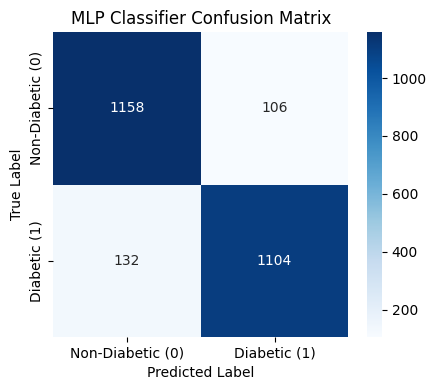

In [17]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[50], activation = 'relu', solver='adam', learning_rate_init=.01, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 5 MODEL - Experiment 58**

Probability Results:  [[0.05870389 0.94129611]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8948

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.89      0.90      1264
    Diabetic (1)       0.89      0.90      0.89      1236

        accuracy                           0.89      2500
       macro avg       0.89      0.89      0.89      2500
    weighted avg       0.89      0.89      0.89      2500

Training Accuracy: 0.9697
Testing Accuracy:  0.8948
Avg F1 Score:      0.8942
Confusion Matrix:
 [[1126  138]
 [ 125 1111]]


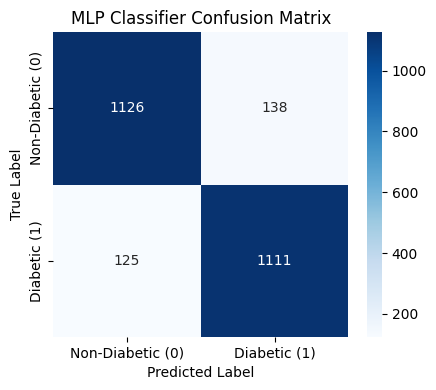

In [18]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50,25], activation = 'relu', solver='adam', learning_rate_init=.01, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 5 MODEL - Experiment 71**

Probability Results:  [[0.35688741 0.64311259]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8964

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.89      0.90      1264
    Diabetic (1)       0.89      0.90      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.8925
Testing Accuracy:  0.8964
Avg F1 Score:      0.8962
Confusion Matrix:
 [[1123  141]
 [ 118 1118]]


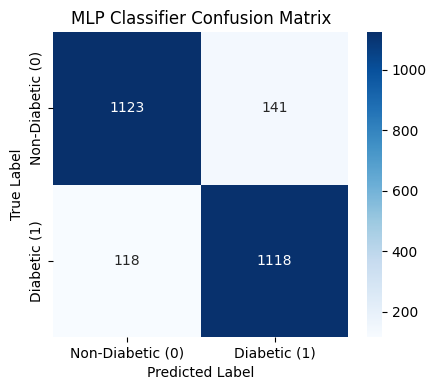

In [19]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[150], activation = 'relu', solver='sgd', learning_rate='constant', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 5 MODEL - Experiment 75**

Probability Results:  [[0.36186478 0.63813522]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8964

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.89      0.90      1264
    Diabetic (1)       0.89      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.8901
Testing Accuracy:  0.8964
Avg F1 Score:      0.8965
Confusion Matrix:
 [[1119  145]
 [ 114 1122]]


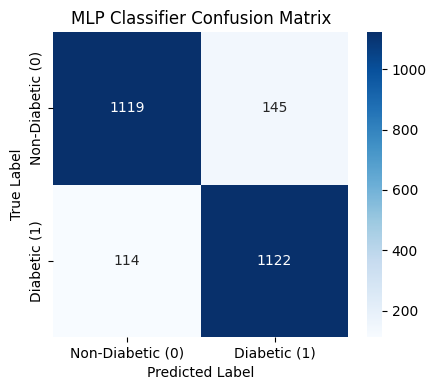

In [20]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[50], activation = 'tanh', solver='sgd', learning_rate='constant', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 5 MODEL - Experiment 79**

Probability Results:  [[0.30281841 0.69718159]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.8984

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.89      0.90      1264
    Diabetic (1)       0.89      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.8968
Testing Accuracy:  0.8984
Avg F1 Score:      0.8981
Confusion Matrix:
 [[1127  137]
 [ 117 1119]]


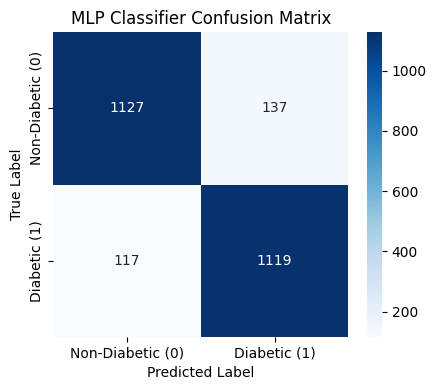

In [21]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50,25], activation = 'relu', solver='sgd', learning_rate='adaptive', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 5 MODEL - Experiment 81**

Probability Results:  [[0.5483384 0.4516616]]
Prediction Results:  [0 0 0 0 0]
Overall Accuracy:  0.7684

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.86      0.65      0.74      1264
    Diabetic (1)       0.71      0.89      0.79      1236

        accuracy                           0.77      2500
       macro avg       0.78      0.77      0.77      2500
    weighted avg       0.79      0.77      0.77      2500

Training Accuracy: 0.7751
Testing Accuracy:  0.7684
Avg F1 Score:      0.7912
Confusion Matrix:
 [[ 824  440]
 [ 139 1097]]


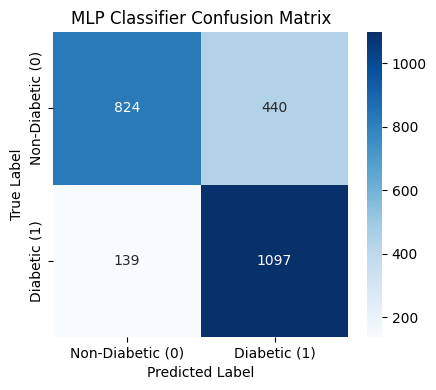

In [22]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[150], activation = 'relu', solver='sgd', learning_rate='invscaling', max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 6 MODEL - Experiment 89**

Probability Results:  [[0.03843101 0.96156899]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9072

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.92      0.90      0.91      1264
    Diabetic (1)       0.90      0.92      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9459
Testing Accuracy:  0.9072
Avg F1 Score:      0.9071
Confusion Matrix:
 [[1135  129]
 [ 103 1133]]


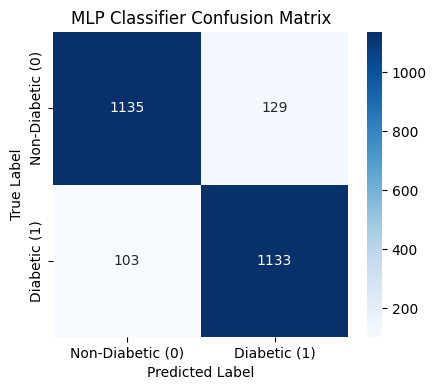

In [25]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100,50,25], activation='relu', solver='sgd', learning_rate='adaptive', batch_size=32, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 6 MODEL - Experiment 100**

Probability Results:  [[0.35421041 0.64578959]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.898

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.91      0.89      0.90      1264
    Diabetic (1)       0.89      0.91      0.90      1236

        accuracy                           0.90      2500
       macro avg       0.90      0.90      0.90      2500
    weighted avg       0.90      0.90      0.90      2500

Training Accuracy: 0.8897
Testing Accuracy:  0.8980
Avg F1 Score:      0.8979
Confusion Matrix:
 [[1124  140]
 [ 115 1121]]


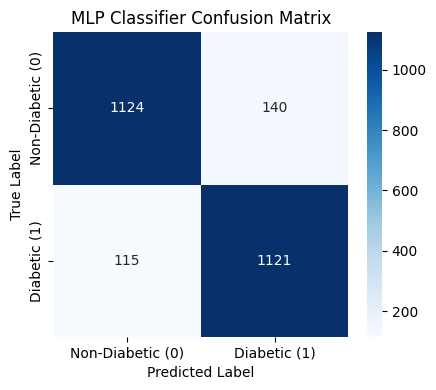

In [26]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[50], activation='tanh', solver='sgd', learning_rate='adaptive', batch_size=512, max_iter=1000, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Hyperparameter 7 MODEL - Experiment 117**

Probability Results:  [[0.02627193 0.97372807]]
Prediction Results:  [1 1 0 0 0]
Overall Accuracy:  0.9124

Classification Report:
                  precision    recall  f1-score   support

Non-Diabetic (0)       0.90      0.93      0.91      1264
    Diabetic (1)       0.92      0.90      0.91      1236

        accuracy                           0.91      2500
       macro avg       0.91      0.91      0.91      2500
    weighted avg       0.91      0.91      0.91      2500

Training Accuracy: 0.9345
Testing Accuracy:  0.9124
Avg F1 Score:      0.9103
Confusion Matrix:
 [[1170   94]
 [ 125 1111]]


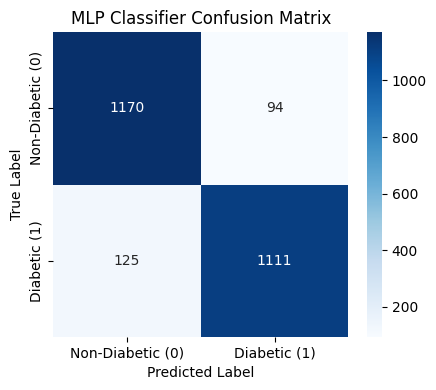

In [28]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('diabetes_clean.csv')

X = df.drop(columns=['is_diabetic'])
y = df['is_diabetic']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nnclf = MLPClassifier(hidden_layer_sizes=[100], activation='relu', solver='adam', learning_rate_init=0.01, max_iter=1500, random_state=0)

nnclf.fit(X_train, y_train)

prob = nnclf.predict_proba(X_test[:1])
print("Probability Results: ", prob)

pred = nnclf.predict(X_test[:5])
print("Prediction Results: ", pred)

score = nnclf.score(X_test, y_test)
print("Overall Accuracy: ", score)

train_acc = nnclf.score(X_train, y_train)
test_acc = nnclf.score(X_test, y_test)

f1 = f1_score(y_test, nnclf.predict(X_test))

y_pred = nnclf.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Diabetic (0)", "Diabetic (1)"]))

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Avg F1 Score:      {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Diabetic (0)", "Diabetic (1)"], yticklabels=["Non-Diabetic (0)", "Diabetic (1)"])
plt.title('MLP Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()